In [360]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import os
import random

In [361]:
def segmentImage(anchor, blockSize=16):
    h, w = anchor.shape
    hSegments = int(h/blockSize)
    wSegments = int(w/blockSize)
    return hSegments, wSegments

In [362]:
def getCenter(x, y, blockSize):
    return int(x + blockSize/2), int(y + blockSize/2)

In [ ]:
def getAnchorSearchArea(x, y, anchor, blockSize, searchArea):
    h, w = anchor.shape
    cx, cy = getCenter(x, y, blockSize)
    sx = max(0, cx-int(blockSize/2)-searchArea)
    sy = max(0, cy-int(blockSize/2)-searchArea)
    anchorSearch = anchor[sy:min(sy+searchArea*2+blockSize, h), sx:min(sx+searchArea*2+blockSize, w)]
    return anchorSearch

In [364]:
def getBlockZone(p, aSearch, tBlock, blockSize):
    px, py = p
    px, py = px-int(blockSize/2), py-int(blockSize/2)
    px, py = max(0,px), max(0, py)
    aBlock = aSearch[py:py+blockSize, px:px+blockSize]
    try:
        assert aBlock.shape == tBlock.shape
    except Exception as e:
        print(e)
    return aBlock

In [365]:
def getMAD(tBlock, aBlock):
    return np.sum(np.abs(np.subtract(tBlock, aBlock))) / (tBlock.shape[0] * tBlock.shape[1])

In [366]:
def getBestMatch(tBlock, aSearch, blockSize):
    step = 4
    ah, aw = aSearch.shape
    acy, acx = int(ah/2), int(aw/2)
    minMAD = float("+inf")
    minP = None
    while step >= 1:
        p1 = (acx, acy)
        p2 = (acx+step, acy)
        p3 = (acx, acy+step)
        p4 = (acx+step, acy+step)
        p5 = (acx-step, acy)
        p6 = (acx, acy-step)
        p7 = (acx-step, acy-step)
        p8 = (acx+step, acy-step)
        p9 = (acx-step, acy+step)
        pointList = [p1, p2, p3, p4, p5, p6, p7, p8, p9]

        for p in range(len(pointList)):
            aBlock = getBlockZone(pointList[p], aSearch, tBlock, blockSize)
            MAD = getMAD(tBlock, aBlock)
            if MAD < minMAD:
                minMAD = MAD
                minP = pointList[p]
        step = int(step/2)

    px, py = minP
    px, py = px - int(blockSize / 2), py - int(blockSize / 2)
    px, py = max(0, px), max(0, py)
    matchBlock = aSearch[py:py + blockSize, px:px + blockSize]
    return matchBlock

In [367]:
def blockSearchBody(anchor, target, blockSize, searchArea=7):
    h, w = anchor.shape
    hSegments, wSegments = segmentImage(anchor, blockSize)
    predicted = np.ones((h, w))*255
    bcount = 0
    for y in range(0, int(hSegments*blockSize), blockSize):
        for x in range(0, int(wSegments*blockSize), blockSize):
            bcount += 1
            targetBlock = target[y:y+blockSize, x:x+blockSize]
            anchorSearchArea = getAnchorSearchArea(x, y, anchor, blockSize, searchArea)
            anchorBlock = getBestMatch(targetBlock, anchorSearchArea, blockSize)
            predicted[y:y+blockSize, x:x+blockSize] = anchorBlock
    assert bcount == int(hSegments*wSegments)
    return predicted

In [368]:
def getResidual(target, predicted):
    return np.subtract(target, predicted)

In [369]:
def getReconstructTarget(residual, predicted):
    return np.add(residual, predicted)

In [370]:
def getBitsPerPixel(im):
    h, w = im.shape
    im_list = im.tolist()
    bits = 0
    for row in im_list:
        for pixel in row:
            bits += math.log2(abs(pixel)+1)
    return bits / (h * w)

In [371]:
def getFrames(filename, first_frame, second_frame):
    cap = cv2.VideoCapture(filename)
    cap.set(cv2.CAP_PROP_POS_FRAMES, first_frame - 1)
    res1, fr1 = cap.read()
    cap.set(cv2.CAP_PROP_POS_FRAMES, second_frame - 1)
    res2, fr2 = cap.read()
    cap.release()
    return fr1, fr2

In [372]:
def main(anchorFrame, targetFrame, saveOutput=False):
    outfile = "./Results"
    blockSize = 16

    bitsAnchor = []
    bitsDiff = []
    bitsPredicted = []
    h, w, ch = anchorFrame.shape
    print(h, w, ch)
    diffFrameRGB = np.zeros((h, w, ch))
    predictedFrameRGB = np.zeros((h, w, ch))
    residualFrameRGB = np.zeros((h, w, ch))
    restoreFrameRGB = np.zeros((h, w, ch))

    for i in range(0, 3):
        anchorFrame_c = anchorFrame[:, :, i]
        targetFrame_c = targetFrame[:, :, i]
        diffFrame = cv2.absdiff(anchorFrame_c, targetFrame_c)
        predictedFrame = blockSearchBody(anchorFrame_c, targetFrame_c, blockSize)
        residualFrame = getResidual(targetFrame_c, predictedFrame)
        reconstructTargetFrame = getReconstructTarget(residualFrame, predictedFrame)
        bitsAnchor += [getBitsPerPixel(anchorFrame_c)]
        bitsDiff += [getBitsPerPixel(diffFrame)]
        bitsPredicted += [getBitsPerPixel(residualFrame)]
        diffFrameRGB[:, :, i] = diffFrame
        predictedFrameRGB[:, :, i] = predictedFrame
        residualFrameRGB[:, :, i] = residualFrame
        restoreFrameRGB[:, :, i] = reconstructTargetFrame

    isdir = os.path.isdir(outfile)
    if not isdir:
        os.mkdir(outfile)
    if saveOutput:
        cv2.imwrite(f"{outfile}/First frame.png", anchorFrame)
        cv2.imwrite(f"{outfile}/Second frame.png", targetFrame)
        cv2.imwrite(f"{outfile}/Difference between frame.png", diffFrameRGB)
        cv2.imwrite(f"{outfile}/Prediction frame.png", predictedFrameRGB)
        cv2.imwrite(f"{outfile}/Residual frame.png", residualFrameRGB)
        cv2.imwrite(f"{outfile}/Restore frame.png", restoreFrameRGB)

    barWidth = 0.25
    fig = plt.subplots(figsize=(12, 8))
    P1 = [sum(bitsAnchor), bitsAnchor[0], bitsAnchor[1], bitsAnchor[2]]
    Diff = [sum(bitsDiff), bitsDiff[0], bitsDiff[1], bitsDiff[2]]
    Mpeg = [sum(bitsPredicted), bitsPredicted[0], bitsPredicted[1], bitsPredicted[2]]
    br1 = np.arange(len(P1))
    br2 = [x + barWidth for x in br1]
    br3 = [x + barWidth for x in br2]
    br4 = [x + barWidth for x in br3]
    plt.bar(br1, P1, color='r', width=barWidth,
    edgecolor='grey', label='Розмір для початкового кадру')
    plt.bar(br2, Diff, color='g', width=barWidth,
    edgecolor='grey', label='Розмір для різниці між кадрами')
    plt.bar(br3, Mpeg, color='b', width=barWidth,
    edgecolor='grey', label='Розмір для різниці з компенсацією рухів')
    plt.title(f'Ступінь стиснення = {round(sum(bitsAnchor)/sum(bitsPredicted), 2)}', fontweight='bold', fontsize=15)
    plt.ylabel('Біт на піксель', fontweight='bold', fontsize=15)
    plt.xticks([r + barWidth for r in range(len(P1))], ['Біт/Піксель RGB', 'Біт/Піксель R', 'Біт/Піксель G', 'Біт/Піксель B'])
    plt.legend()
    plt.savefig(f'{outfile}/Гістограма кількості біт на піксель для різних варіантів кодування.png', dpi=600)

720 1280 3


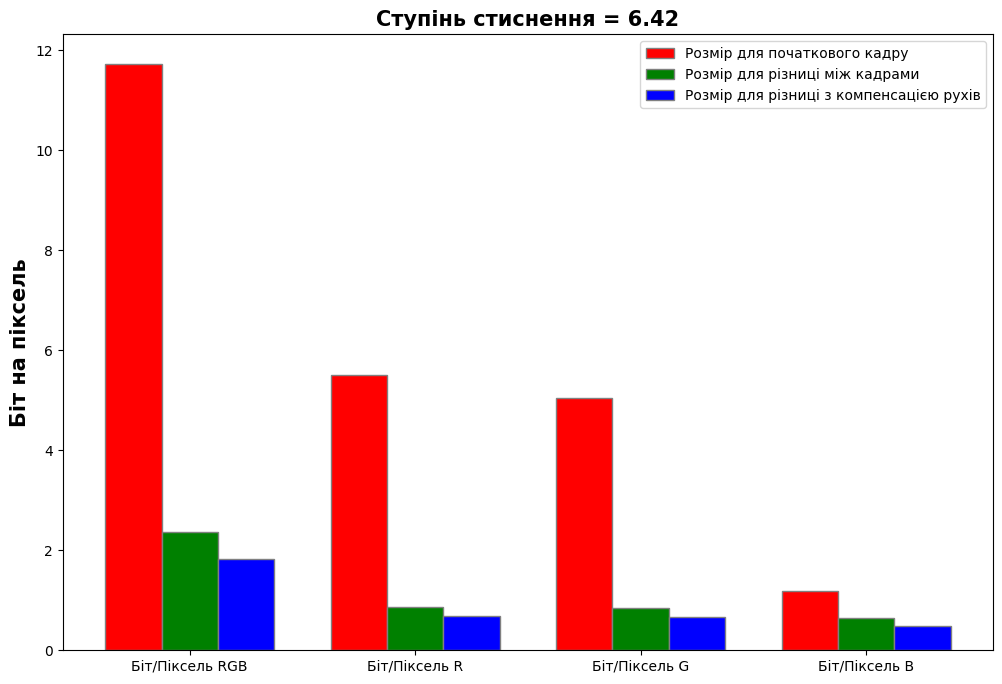

In [373]:
if __name__ == "__main__":
    fr = random.randint(0, 3000)
    frame1, frame2 = getFrames('sample4.wm', fr, fr + 1)
    main(frame1, frame2, saveOutput=True)